In [2]:
import sys
sys.path.append('..')
from common_helper_functions import *


In [3]:
path = "../../../../../../../../../../../s/project/yeast_gxg/data/orthrus_data/"

canonical_transcripts = pd.read_csv(path + "canonical_transcripts.csv")


In [4]:
canonical_transcripts

,gene_ID,mRNA_ID
0,ENSG00000293532,NM_002457.5
1,ENSG00000288488,NM_138352.3
2,ENSG00000281766,NM_012234.7
3,ENSG00000292254,NM_001372044.2
4,ENSG00000114374,NM_004654.4
...,...,...
19333,ENSG00000271425,NM_001302371.3
19334,ENSG00000188157,NM_198576.4
19335,ENSG00000152092,NM_004319.3
19336,ENSG00000236719,NR_125716.2


In [5]:
file = open(path + "/human_cdna_embeds.pkl",'rb')
orthrus_emb = pickle.load(file)
file.close()
orthrus_emb = pd.DataFrame(orthrus_emb)
orthrus_emb

,NR_046018.2,NR_024540.1,NR_106918.1,XR_007065314.1,NR_036051.1,NR_026818.1,NM_001005484.2,XR_007065337.1,XR_007065338.1,XR_001737579.3,...,XM_054333502.1,XM_054333501.1,XM_054333503.1,XM_054333506.1,XM_054333505.1,XM_054333504.1,XM_054333508.1,XM_054333507.1,XM_054333509.1,XR_008485847.1
0,-0.047842,0.032107,-0.049374,-0.070154,-0.009447,-0.046102,-0.067097,-0.038941,-0.042657,0.002135,...,-0.031667,-0.032828,-0.028554,-0.066021,-0.082933,-0.058773,-0.036795,-0.025417,-0.028733,-0.141210
1,-0.052616,-0.056019,-0.117312,-0.055393,-0.094807,-0.063681,-0.037259,-0.044432,-0.043342,-0.046993,...,-0.093992,-0.110541,-0.091597,-0.091098,-0.092311,-0.102791,-0.091743,-0.092424,-0.069852,-0.063763
2,0.007195,0.007170,-0.058886,0.010893,-0.052286,0.007030,0.066265,0.014664,0.013452,0.052339,...,0.017758,0.028400,0.024704,0.007477,-0.017011,0.036187,0.011026,0.065347,0.080960,0.020660
3,-0.301619,-0.289998,-0.283026,-0.288541,-0.334369,-0.325219,-0.248337,-0.235638,-0.235420,-0.286686,...,-0.236302,-0.236592,-0.253983,-0.237570,-0.240467,-0.259547,-0.248849,-0.227785,-0.262493,-0.304562
4,-0.276823,-0.309537,-0.183289,-0.221346,-0.264196,-0.233912,-0.146096,-0.198080,-0.195286,-0.211631,...,-0.194292,-0.212328,-0.235818,-0.208636,-0.229666,-0.227536,-0.189040,-0.211790,-0.276499,-0.275551
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,0.061786,0.027622,0.026404,0.069871,0.024482,0.025514,0.095052,0.049054,0.050432,0.067742,...,0.093980,0.078311,0.139621,0.083571,0.101252,0.134301,0.093203,0.140814,0.106100,0.134321
252,0.345473,0.273920,0.163171,0.315414,0.224057,0.336981,0.240443,0.276451,0.280836,0.254847,...,0.231664,0.253359,0.318591,0.300788,0.270761,0.298349,0.214690,0.297420,0.333445,0.270484
253,0.550452,0.526121,0.409989,0.571907,0.528892,0.540720,0.458000,0.524165,0.528575,0.536035,...,0.479441,0.465995,0.485162,0.491396,0.498841,0.525531,0.478868,0.492418,0.549169,0.520365
254,-0.359427,-0.317423,-0.299750,-0.310197,-0.246938,-0.342683,-0.305856,-0.291196,-0.292847,-0.289203,...,-0.324380,-0.354211,-0.363853,-0.351674,-0.352810,-0.360686,-0.320871,-0.362872,-0.342787,-0.351752


In [6]:
orthrus_emb.columns = orthrus_emb.columns.astype(str)
mrna_to_gene = dict(zip(canonical_transcripts["mRNA_ID"], canonical_transcripts["gene_ID"]))
orthrus_renamed = orthrus_emb.rename(columns=mrna_to_gene)

In [7]:
orthrus_renamed

,NR_046018.2,NR_024540.1,NR_106918.1,XR_007065314.1,NR_036051.1,NR_026818.1,ENSG00000186092,XR_007065337.1,XR_007065338.1,XR_001737579.3,...,XM_054333502.1,XM_054333501.1,XM_054333503.1,XM_054333506.1,XM_054333505.1,XM_054333504.1,XM_054333508.1,XM_054333507.1,XM_054333509.1,XR_008485847.1
0,-0.047842,0.032107,-0.049374,-0.070154,-0.009447,-0.046102,-0.067097,-0.038941,-0.042657,0.002135,...,-0.031667,-0.032828,-0.028554,-0.066021,-0.082933,-0.058773,-0.036795,-0.025417,-0.028733,-0.141210
1,-0.052616,-0.056019,-0.117312,-0.055393,-0.094807,-0.063681,-0.037259,-0.044432,-0.043342,-0.046993,...,-0.093992,-0.110541,-0.091597,-0.091098,-0.092311,-0.102791,-0.091743,-0.092424,-0.069852,-0.063763
2,0.007195,0.007170,-0.058886,0.010893,-0.052286,0.007030,0.066265,0.014664,0.013452,0.052339,...,0.017758,0.028400,0.024704,0.007477,-0.017011,0.036187,0.011026,0.065347,0.080960,0.020660
3,-0.301619,-0.289998,-0.283026,-0.288541,-0.334369,-0.325219,-0.248337,-0.235638,-0.235420,-0.286686,...,-0.236302,-0.236592,-0.253983,-0.237570,-0.240467,-0.259547,-0.248849,-0.227785,-0.262493,-0.304562
4,-0.276823,-0.309537,-0.183289,-0.221346,-0.264196,-0.233912,-0.146096,-0.198080,-0.195286,-0.211631,...,-0.194292,-0.212328,-0.235818,-0.208636,-0.229666,-0.227536,-0.189040,-0.211790,-0.276499,-0.275551
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,0.061786,0.027622,0.026404,0.069871,0.024482,0.025514,0.095052,0.049054,0.050432,0.067742,...,0.093980,0.078311,0.139621,0.083571,0.101252,0.134301,0.093203,0.140814,0.106100,0.134321
252,0.345473,0.273920,0.163171,0.315414,0.224057,0.336981,0.240443,0.276451,0.280836,0.254847,...,0.231664,0.253359,0.318591,0.300788,0.270761,0.298349,0.214690,0.297420,0.333445,0.270484
253,0.550452,0.526121,0.409989,0.571907,0.528892,0.540720,0.458000,0.524165,0.528575,0.536035,...,0.479441,0.465995,0.485162,0.491396,0.498841,0.525531,0.478868,0.492418,0.549169,0.520365
254,-0.359427,-0.317423,-0.299750,-0.310197,-0.246938,-0.342683,-0.305856,-0.291196,-0.292847,-0.289203,...,-0.324380,-0.354211,-0.363853,-0.351674,-0.352810,-0.360686,-0.320871,-0.362872,-0.342787,-0.351752


In [8]:
ensg_mask = orthrus_renamed.columns.str.startswith("ENSG")
orthrus_renamed = orthrus_renamed.loc[:, ensg_mask]

In [9]:
orthrus_renamed

,ENSG00000186092,ENSG00000284733,ENSG00000284662,ENSG00000187634,ENSG00000188976,ENSG00000187961,ENSG00000187583,ENSG00000187642,ENSG00000188290,ENSG00000187608,...,ENSG00000277897,ENSG00000277656,ENSG00000262156,ENSG00000277768,ENSG00000282604,ENSG00000249103,ENSG00000231021,ENSG00000227746,ENSG00000233312,ENSG00000274707
0,-0.067097,-0.150649,-0.150649,-0.006247,-0.026891,-0.049677,-0.008502,-0.050623,-0.015213,-0.017853,...,-0.050080,-0.095216,0.012951,-0.055662,-0.078677,-0.072991,-0.001423,-0.076978,-0.077193,-0.034816
1,-0.037259,0.019089,0.019089,-0.030746,-0.187528,-0.079461,-0.126054,-0.043918,-0.019686,-0.064556,...,-0.056969,-0.108128,-0.073384,0.003592,-0.043736,0.018168,-0.078294,0.000924,-0.000004,-0.109873
2,0.066265,0.089471,0.089471,0.007557,0.040384,-0.008257,-0.042163,-0.025070,-0.016417,0.111959,...,0.111034,0.100775,-0.007046,0.039238,0.034063,0.098292,0.038144,0.228093,0.229113,0.031260
3,-0.248337,-0.296814,-0.296814,-0.341929,-0.251638,-0.301110,-0.269467,-0.288543,-0.354139,-0.368153,...,-0.303271,-0.298436,-0.283799,-0.299550,-0.294511,-0.276266,-0.218092,-0.370173,-0.366380,-0.237259
4,-0.146096,-0.137837,-0.137837,-0.275867,-0.270066,-0.235039,-0.244751,-0.288339,-0.155096,-0.337710,...,-0.397605,-0.360308,-0.252466,-0.271675,-0.268950,-0.121552,-0.298642,-0.413501,-0.416127,-0.212323
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,0.095052,0.079414,0.079414,0.067865,0.118810,0.028968,0.098907,0.014458,0.100637,0.040556,...,0.078072,0.104515,0.133795,0.031809,0.038748,0.169864,0.040725,0.140523,0.141977,0.079022
252,0.240443,0.296015,0.296015,0.291427,0.147759,0.269868,0.284692,0.354893,0.362245,0.331372,...,0.283725,0.306395,0.291330,0.240622,0.275819,0.195653,0.306769,0.448572,0.445949,0.253076
253,0.458000,0.542012,0.542012,0.626837,0.584304,0.592215,0.478034,0.632594,0.560677,0.662974,...,0.511057,0.463297,0.476772,0.529384,0.451462,0.451084,0.561216,0.507425,0.510589,0.466747
254,-0.305856,-0.324910,-0.324910,-0.287346,-0.341943,-0.373347,-0.319118,-0.371641,-0.263308,-0.326698,...,-0.309476,-0.302145,-0.303749,-0.295450,-0.322610,-0.350819,-0.364538,-0.270410,-0.270349,-0.355033


In [10]:
orthrus_transposed = orthrus_renamed.T
orthrus_transposed = orthrus_transposed.reset_index().rename(columns={'index': 'gene_id'})
orthrus_transposed

,gene_id,0,1,2,3,4,5,6,7,8,...,246,247,248,249,250,251,252,253,254,255
0,ENSG00000186092,-0.067097,-0.037259,0.066265,-0.248337,-0.146096,0.027085,-0.274174,-0.161956,-0.019774,...,0.054242,0.242999,0.133815,-0.233959,-0.092769,0.095052,0.240443,0.458000,-0.305856,0.425528
1,ENSG00000284733,-0.150649,0.019089,0.089471,-0.296814,-0.137837,0.110006,-0.234172,-0.173813,-0.100771,...,0.074931,0.243074,0.104836,-0.261771,-0.040988,0.079414,0.296015,0.542012,-0.324910,0.444035
2,ENSG00000284662,-0.150649,0.019089,0.089471,-0.296814,-0.137837,0.110006,-0.234172,-0.173813,-0.100771,...,0.074931,0.243074,0.104836,-0.261771,-0.040988,0.079414,0.296015,0.542012,-0.324910,0.444035
3,ENSG00000187634,-0.006247,-0.030746,0.007557,-0.341929,-0.275867,-0.058499,-0.329511,-0.167096,0.002317,...,0.058948,0.278398,0.208794,-0.236242,-0.101434,0.067865,0.291427,0.626837,-0.287346,0.327884
4,ENSG00000188976,-0.026891,-0.187528,0.040384,-0.251638,-0.270066,-0.124310,-0.328415,-0.133666,-0.095739,...,0.068438,0.202657,0.150870,-0.125065,-0.039511,0.118810,0.147759,0.584304,-0.341943,0.377747
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19333,ENSG00000249103,-0.072991,0.018168,0.098292,-0.276266,-0.121552,0.063039,-0.284849,-0.200161,0.002627,...,0.091684,0.262072,0.132654,-0.283492,-0.031500,0.169864,0.195653,0.451084,-0.350819,0.399496
19334,ENSG00000231021,-0.001423,-0.078294,0.038144,-0.218092,-0.298642,-0.067565,-0.294970,-0.131460,-0.064628,...,0.026637,0.209670,0.311289,-0.210989,-0.147207,0.040725,0.306769,0.561216,-0.364538,0.331297
19335,ENSG00000227746,-0.076978,0.000924,0.228093,-0.370173,-0.413501,-0.027046,0.143914,-0.242841,0.000517,...,0.106917,0.203670,0.251873,-0.164335,-0.135491,0.140523,0.448572,0.507425,-0.270410,0.354155
19336,ENSG00000233312,-0.077193,-0.000004,0.229113,-0.366380,-0.416127,-0.029360,0.140863,-0.244427,0.002347,...,0.107454,0.205529,0.252420,-0.168219,-0.133900,0.141977,0.445949,0.510589,-0.270349,0.355909


In [11]:
orthrus_transposed.to_csv("../../preprocessed_data/orthrus_processed.csv", index=False)

In [12]:
emogi_predictions = pd.read_csv('../../../../../../../../../s/project/gene_embedding/input_data/cancer_eval/emogi_predictions.tsv', sep='\t')
emogi_predictions

,ID,Name,label,Prob_pos_1,Prob_pos_2,Prob_pos_3,Prob_pos_4,Prob_pos_5,Prob_pos_6,Prob_pos_7,...,Prob_pos_9,Prob_pos_10,Num_Pos,Mean_Pred,Std_Pred,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene,ONGene_Oncogene
0,ENSG00000100393,EP300,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
1,ENSG00000133703,KRAS,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
2,ENSG00000155657,TTN,False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,False,True,False,False,False
3,ENSG00000284792,PTEN,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
4,ENSG00000039068,CDH1,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13622,ENSG00000266200,PNLIPRP2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13623,ENSG00000125375,DMAC2L,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13624,ENSG00000173662,TAS1R1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13625,ENSG00000197084,LCE1C,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False


In [13]:
cancer_gene_columns = emogi_predictions[['ID', "NCG_Known_Cancer_Gene", "NCG_Candidate_Cancer_Gene", "OncoKB_Cancer_Gene", "Bailey_et_al_Cancer_Gene"]]
merged = orthrus_transposed.merge(cancer_gene_columns, left_on='gene_id', right_on='ID', how='inner').drop(columns=['ID'])
merged.set_index('gene_id', inplace=True)
merged

,0,1,2,3,4,5,6,7,8,9,...,250,251,252,253,254,255,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000187634,-0.006247,-0.030746,0.007557,-0.341929,-0.275867,-0.058499,-0.329511,-0.167096,0.002317,0.202269,...,-0.101434,0.067865,0.291427,0.626837,-0.287346,0.327884,False,False,False,False
ENSG00000188976,-0.026891,-0.187528,0.040384,-0.251638,-0.270066,-0.124310,-0.328415,-0.133666,-0.095739,0.172667,...,-0.039511,0.118810,0.147759,0.584304,-0.341943,0.377747,False,False,False,False
ENSG00000187961,-0.049677,-0.079461,-0.008257,-0.301110,-0.235039,-0.079872,-0.318997,-0.150227,-0.060366,0.262209,...,-0.108249,0.028968,0.269868,0.592215,-0.373347,0.398238,False,False,False,False
ENSG00000188290,-0.015213,-0.019686,-0.016417,-0.354139,-0.155096,-0.052826,-0.274841,-0.150890,-0.015334,0.226402,...,-0.170332,0.100637,0.362245,0.560677,-0.263308,0.328459,False,False,False,False
ENSG00000187608,-0.017853,-0.064556,0.111959,-0.368153,-0.337710,-0.160168,-0.332272,-0.198787,-0.037595,0.253953,...,-0.205590,0.040556,0.331372,0.662974,-0.326698,0.347235,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000276175,0.062180,-0.073835,0.057919,-0.257301,-0.287413,0.083006,-0.178685,-0.134302,-0.164164,0.162841,...,-0.172390,0.085553,0.420324,0.504836,-0.370253,0.393709,False,False,False,False
ENSG00000277656,-0.095216,-0.108128,0.100775,-0.298436,-0.360308,-0.030366,-0.280311,-0.089956,-0.049733,0.233837,...,-0.183971,0.104515,0.306395,0.463297,-0.302145,0.382332,False,False,False,False
ENSG00000262156,0.012951,-0.073384,-0.007046,-0.283799,-0.252466,-0.058139,-0.304810,-0.123882,-0.069055,0.182771,...,-0.083188,0.133795,0.291330,0.476772,-0.303749,0.348084,False,False,False,False


## Predict NCG_Known_Cancer_Gene

In [14]:
merged['NCG_Known_Cancer_Gene'].value_counts()

NCG_Known_Cancer_Gene
False    12321
True       626
Name: count, dtype: int64

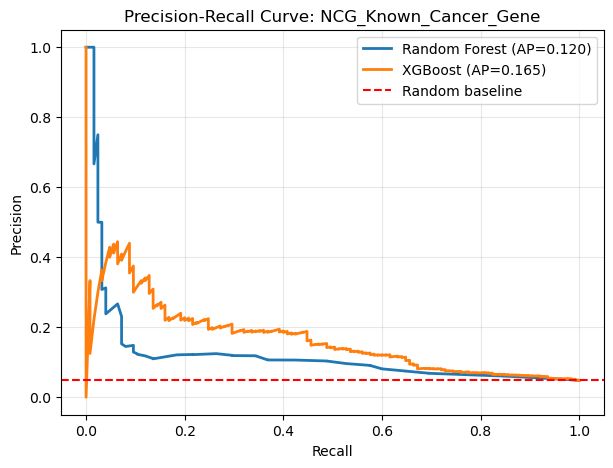

Random Forest - auPRC: 0.120
XGBoost - auPRC: 0.165



In [15]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Candidate_Cancer_Gene', 'Bailey_et_al_Cancer_Gene', 'OncoKB_Cancer_Gene']), 'NCG_Known_Cancer_Gene')

## NCG_Candidate_Cancer_Gene

In [16]:
merged['NCG_Candidate_Cancer_Gene'].value_counts()

NCG_Candidate_Cancer_Gene
False    11730
True      1217
Name: count, dtype: int64

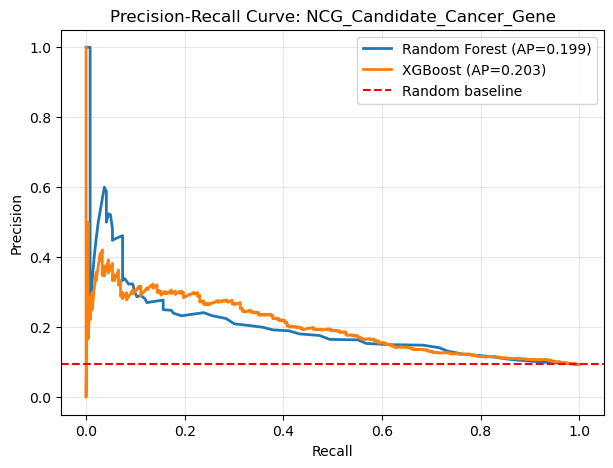

Random Forest - auPRC: 0.199
XGBoost - auPRC: 0.203



In [17]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Known_Cancer_Gene', 'OncoKB_Cancer_Gene', 'Bailey_et_al_Cancer_Gene']), 'NCG_Candidate_Cancer_Gene')

## OncoKB_Cancer_Gene

In [18]:
merged['OncoKB_Cancer_Gene'].value_counts()

OncoKB_Cancer_Gene
False    12450
True       497
Name: count, dtype: int64

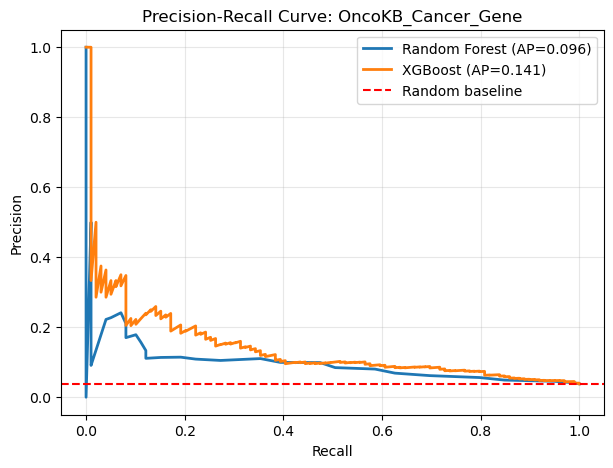

Random Forest - auPRC: 0.096
XGBoost - auPRC: 0.141



In [19]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Candidate_Cancer_Gene', 'NCG_Known_Cancer_Gene', 'Bailey_et_al_Cancer_Gene']), 'OncoKB_Cancer_Gene')

## Bailey_et_al_Cancer_Gene

In [20]:
merged['Bailey_et_al_Cancer_Gene'].value_counts()

Bailey_et_al_Cancer_Gene
False    12679
True       268
Name: count, dtype: int64

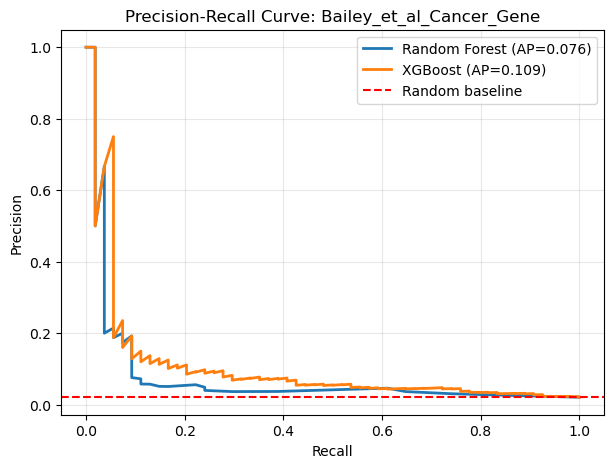

Random Forest - auPRC: 0.076
XGBoost - auPRC: 0.109



In [21]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Candidate_Cancer_Gene', 'NCG_Known_Cancer_Gene', 'OncoKB_Cancer_Gene']), 'Bailey_et_al_Cancer_Gene')